# Energy Consumption Optimizer
**Case Study | Regression | Smart City Hourly Electricity Load Prediction**

**Problem Statement:**  
A smart-city project needs to predict the hourly electricity load of a neighborhood to optimize power distribution.

**ML Task:** Regression  
**Focus:** Feature Scaling (StandardScaler / MinMaxScaler) 

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print('All libraries imported successfully.')

All libraries imported successfully.


In [15]:
np.random.seed(42)
n = 8760  # 1 year of hourly electricity data (8760 hours = 24 x 365)

hours       = np.arange(n) % 24
days        = np.arange(n) // 24
day_of_week = days % 7
month       = (days // 30) % 12 + 1
is_weekend  = (day_of_week >= 5).astype(int)

# Simulate temperature: warmer in summer, cooler in winter
temperature = 20 + 10 * np.sin(2 * np.pi * days / 365) + np.random.normal(0, 3, n)

humidity = np.random.uniform(40, 90, n)

# Simulate electricity load (based on time of day, temperature, and weekend)
electricity_load = (
    300
    + 100 * np.sin(np.pi * (hours - 6) / 12)  # higher during daytime
    + 2.5 * np.abs(temperature - 22)           # extreme temp = more electricity
    - 30  * is_weekend                          # less usage on weekends
    + np.random.normal(0, 20, n)               # random noise
)
electricity_load = np.clip(electricity_load, 100, 700)

df = pd.DataFrame({
    'hour'            : hours,
    'day_of_week'     : day_of_week,
    'month'           : month,
    'temperature'     : np.round(temperature, 2),
    'humidity'        : np.round(humidity, 2),
    'is_weekend'      : is_weekend,
    'electricity_load': np.round(electricity_load, 2)
})

# Add missing values (simulating sensor failures)
df.loc[np.random.choice(n, 80, replace=False), 'temperature'] = np.nan
df.loc[np.random.choice(n, 60, replace=False), 'humidity']    = np.nan

# Add duplicate rows (simulating duplicate records)
df = pd.concat([df, df.sample(30, random_state=42)], ignore_index=True)

df.head(10)

,hour,day_of_week,month,temperature,humidity,is_weekend,electricity_load
0,0,0,1,21.49,54.61,0,225.16
1,1,0,1,19.59,72.79,0,239.99
2,2,0,1,21.94,72.08,0,203.90
3,3,0,1,24.57,50.47,0,240.44
4,4,0,1,19.30,41.52,0,238.94
5,5,0,1,19.30,61.68,0,241.91
6,6,0,1,24.74,68.48,0,292.07
7,7,0,1,22.30,83.83,0,315.83
8,8,0,1,18.59,86.41,0,351.42
9,9,0,1,21.63,66.44,0,352.46


In [16]:
print('Shape (rows, columns):')
print(df.shape)

print('\nData types of each column:')
print(df.dtypes)

print('\nMissing values in each column:')
print(df.isnull().sum())

print('\nNumber of duplicate rows:')
print(df.duplicated().sum())

print('\nBasic statistics:')
df.describe()

Shape (rows, columns):
(8790, 7)

Data types of each column:
hour                  int64
day_of_week           int64
month                 int64
temperature         float64
humidity            float64
is_weekend            int64
electricity_load    float64
dtype: object

Missing values in each column:
hour                 0
day_of_week          0
month                0
temperature         81
humidity            60
is_weekend           0
electricity_load     0
dtype: int64

Number of duplicate rows:
30

Basic statistics:


,hour,day_of_week,month,temperature,humidity,is_weekend,electricity_load
count,8790.000000,8790.000000,8790.000000,8709.000000,8730.000000,8790.000000,8790.000000
mean,11.499545,2.990671,6.427645,19.990366,65.190979,0.284755,308.648832
std,6.922071,2.003616,3.486519,7.749731,14.468490,0.451324,75.245662
min,0.000000,0.000000,1.000000,1.130000,40.010000,0.000000,124.550000
25%,6.000000,1.000000,3.000000,13.340000,52.672500,0.000000,242.222500
50%,11.000000,3.000000,6.000000,20.080000,65.255000,0.000000,308.465000
75%,17.750000,5.000000,9.000000,26.670000,77.770000,1.000000,374.887500
max,23.000000,6.000000,12.000000,40.580000,90.000000,1.000000,491.860000


In [17]:
# Impute missing values with column mean and remove duplicate rows
df['temperature'] = df['temperature'].fillna(df['temperature'].mean())
df['humidity'] = df['humidity'].fillna(df['humidity'].mean())

df = df.drop_duplicates().reset_index(drop=True)

print('Data cleaned.')
print('Rows after cleaning:', len(df))
print('Missing values left:', df.isnull().sum().sum())
print('Duplicate rows left:', df.duplicated().sum())

Data cleaned.
Rows after cleaning: 8760
Missing values left: 0
Duplicate rows left: 0


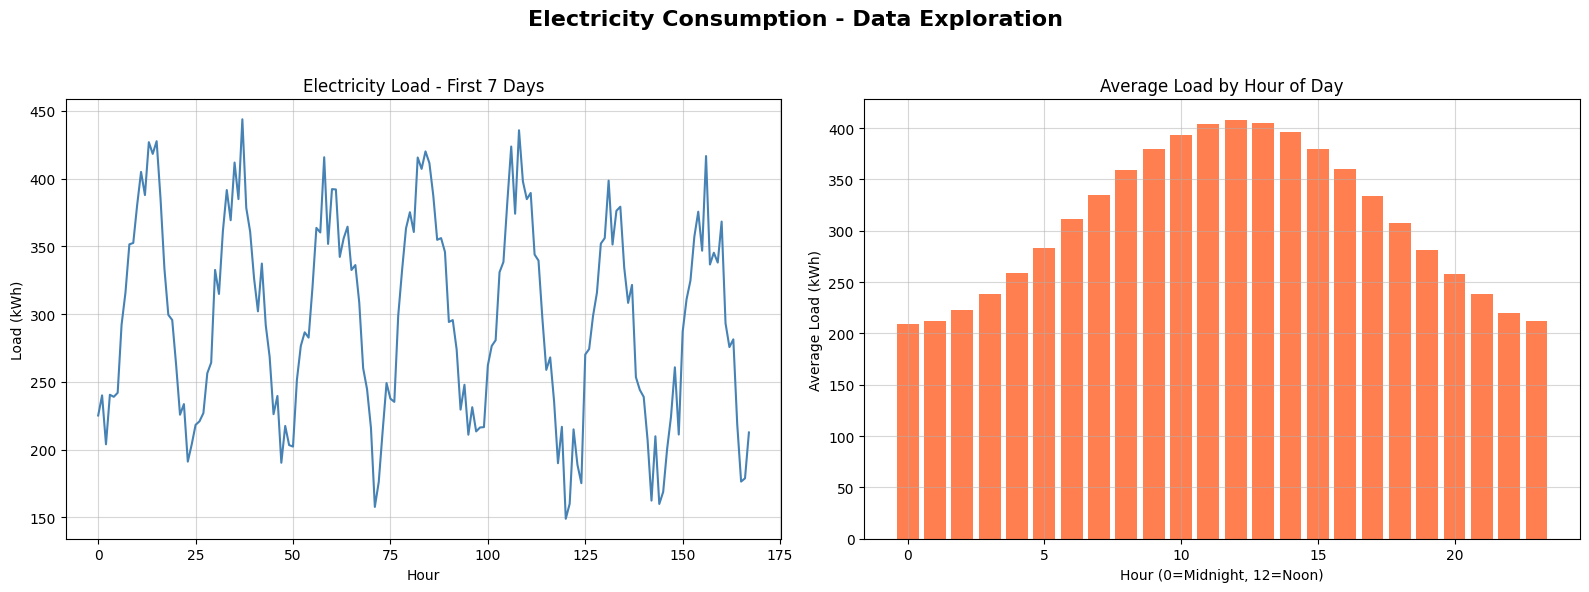

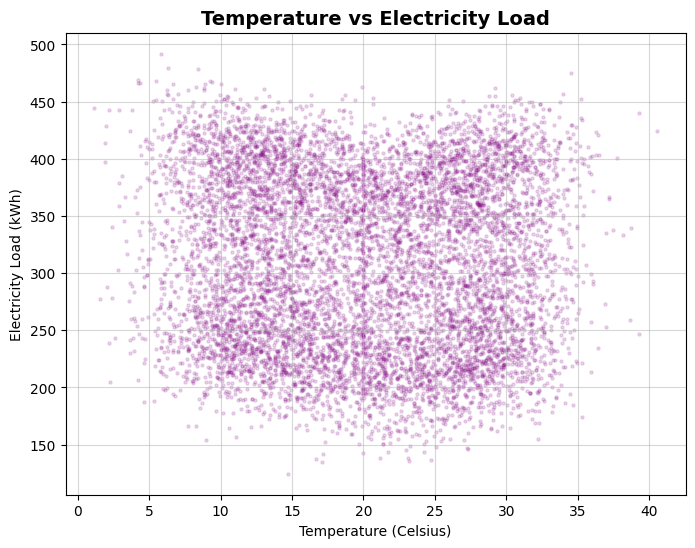

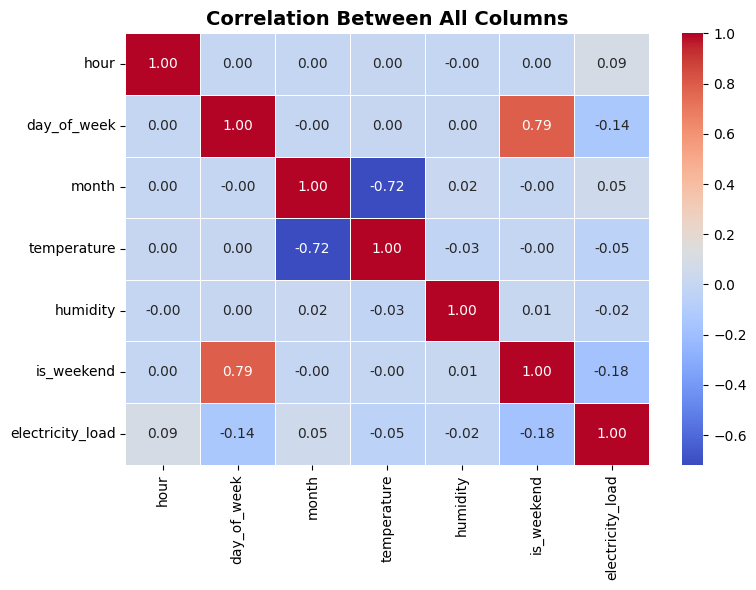

In [18]:
plt.figure(figsize=(16, 6))
plt.suptitle('Electricity Consumption - Data Exploration', fontsize=16, fontweight='bold', y=0.98)

plt.subplot(1, 2, 1)
plt.plot(df['electricity_load'][:168], color='steelblue')
plt.title('Electricity Load - First 7 Days')
plt.xlabel('Hour')
plt.ylabel('Load (kWh)')
plt.grid(True, linestyle='-', alpha=0.5)

plt.subplot(1, 2, 2)
hourly_avg = df.groupby('hour')['electricity_load'].mean()
plt.bar(hourly_avg.index, hourly_avg.values, color='coral')
plt.title('Average Load by Hour of Day')
plt.xlabel('Hour (0=Midnight, 12=Noon)')
plt.ylabel('Average Load (kWh)')
plt.grid(True, linestyle='-', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['temperature'], df['electricity_load'], color='purple', alpha=0.15, s=5)
plt.title('Temperature vs Electricity Load', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Electricity Load (kWh)')
plt.grid(True, linestyle='-', alpha=0.5)
# plt.savefig('temperature_vs_load.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between All Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
X = df.drop('electricity_load', axis=1)
y = df['electricity_load']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Features used to predict:', list(X.columns))
print('Target column: electricity_load')
print()
print('Training rows:', len(X_train), '(80%)')
print('Testing rows :', len(X_test),  '(20%)')

Features used to predict: ['hour', 'day_of_week', 'month', 'temperature', 'humidity', 'is_weekend']
Target column: electricity_load

Training rows: 7008 (80%)
Testing rows : 1752 (20%)


In [20]:
# Feature Scaling: Bring features to a similar scale to improve model performance
# StandardScaler: sets mean = 0, variance = 1
# MinMaxScaler: scales values between 0 and 1

# StandardScaler
standard_scaler  = StandardScaler()
X_train_scaled   = standard_scaler.fit_transform(X_train)
X_test_scaled    = standard_scaler.transform(X_test)

print('StandardScaler:')
print('  Temperature before scaling — min:', round(X_train['temperature'].min(), 2),
      ' max:', round(X_train['temperature'].max(), 2))
print('  Temperature after scaling  — min:', round(X_train_scaled[:, 3].min(), 2),
      ' max:', round(X_train_scaled[:, 3].max(), 2))
print('  Mean after scaling (should be near 0):', round(X_train_scaled[:, 3].mean(), 4))

print()

# MinMaxScaler
minmax_scaler  = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax  = minmax_scaler.transform(X_test)

print('MinMaxScaler:')
print('  Temperature after scaling — min:', round(X_train_minmax[:, 3].min(), 2),
      ' max:', round(X_train_minmax[:, 3].max(), 2))
print('  All values should now be between 0 and 1')

StandardScaler:
  Temperature before scaling — min: 1.13  max: 40.58
  Temperature after scaling  — min: -2.46  max: 2.67
  Mean after scaling (should be near 0): 0.0

MinMaxScaler:
  Temperature after scaling — min: 0.0  max: 1.0
  All values should now be between 0 and 1


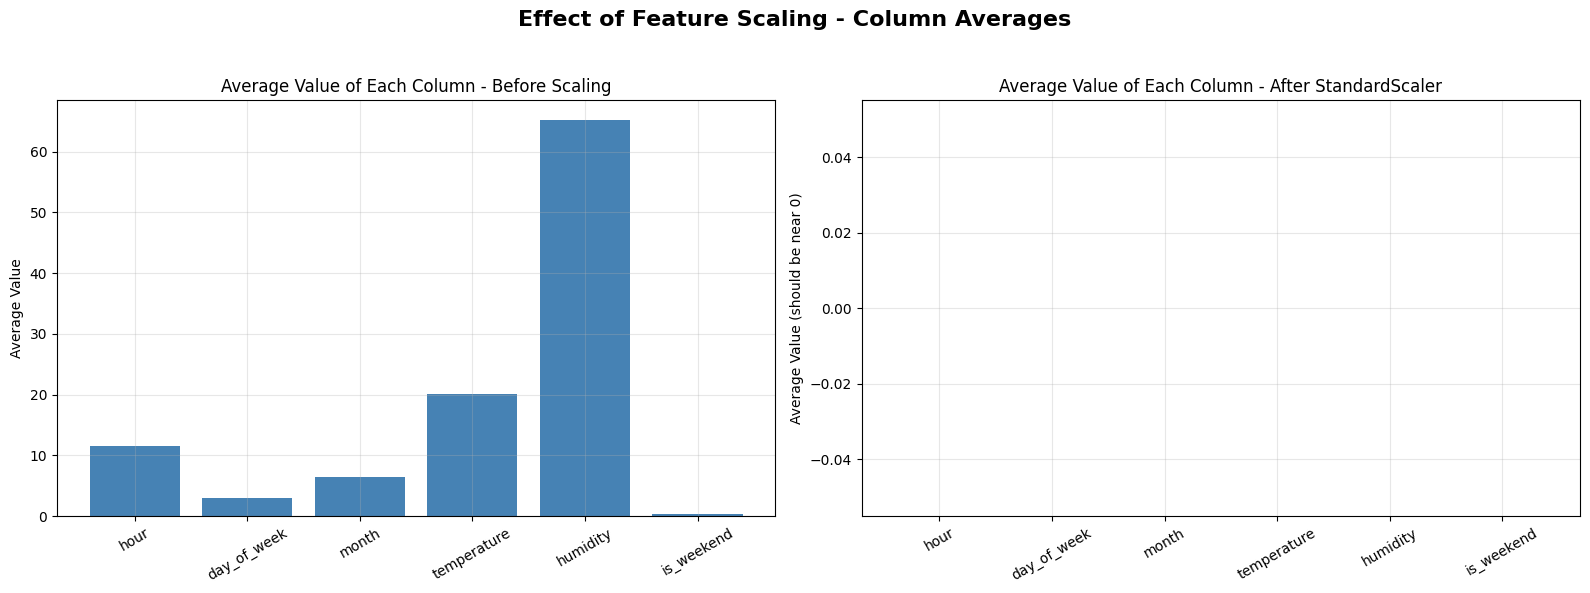

In [21]:
col_names = list(X.columns)

before_means = [round(X_train[col].mean(), 2) for col in col_names]
after_means  = [round(X_train_scaled[:, i].mean(), 4) for i in range(len(col_names))]

plt.figure(figsize=(16, 6))
plt.suptitle('Effect of Feature Scaling - Column Averages', fontsize=16, fontweight='bold', y=0.98)

plt.subplot(1, 2, 1)
plt.bar(col_names, before_means, color='steelblue')
plt.title('Average Value of Each Column - Before Scaling')
plt.ylabel('Average Value')
plt.xticks(rotation=30)
plt.grid(True, linestyle='-', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(col_names, after_means, color='seagreen')
plt.title('Average Value of Each Column - After StandardScaler')
plt.ylabel('Average Value (should be near 0)')
plt.xticks(rotation=30)
plt.grid(True, linestyle='-', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Train Linear Regression and Random Forest models on scaled data
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
print('Linear Regression trained.')

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
print('Random Forest trained.')

Linear Regression trained.
Random Forest trained.


In [23]:
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2  = r2_score(y_test, lr_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2  = r2_score(y_test, rf_predictions)

print('=== Model Evaluation ===')
print()
print('Linear Regression')
print('  MSE :', round(lr_mse, 2))
print('  R2  :', round(lr_r2, 4), '--->', round(lr_r2 * 100, 2), '% accurate')
print()
print('Random Forest')
print('  MSE :', round(rf_mse, 2))
print('  R2  :', round(rf_r2, 4), '--->', round(rf_r2 * 100, 2), '% accurate')

=== Model Evaluation ===

Linear Regression
  MSE : 5424.45
  R2  : 0.0192 ---> 1.92 % accurate

Random Forest
  MSE : 491.14
  R2  : 0.9112 ---> 91.12 % accurate


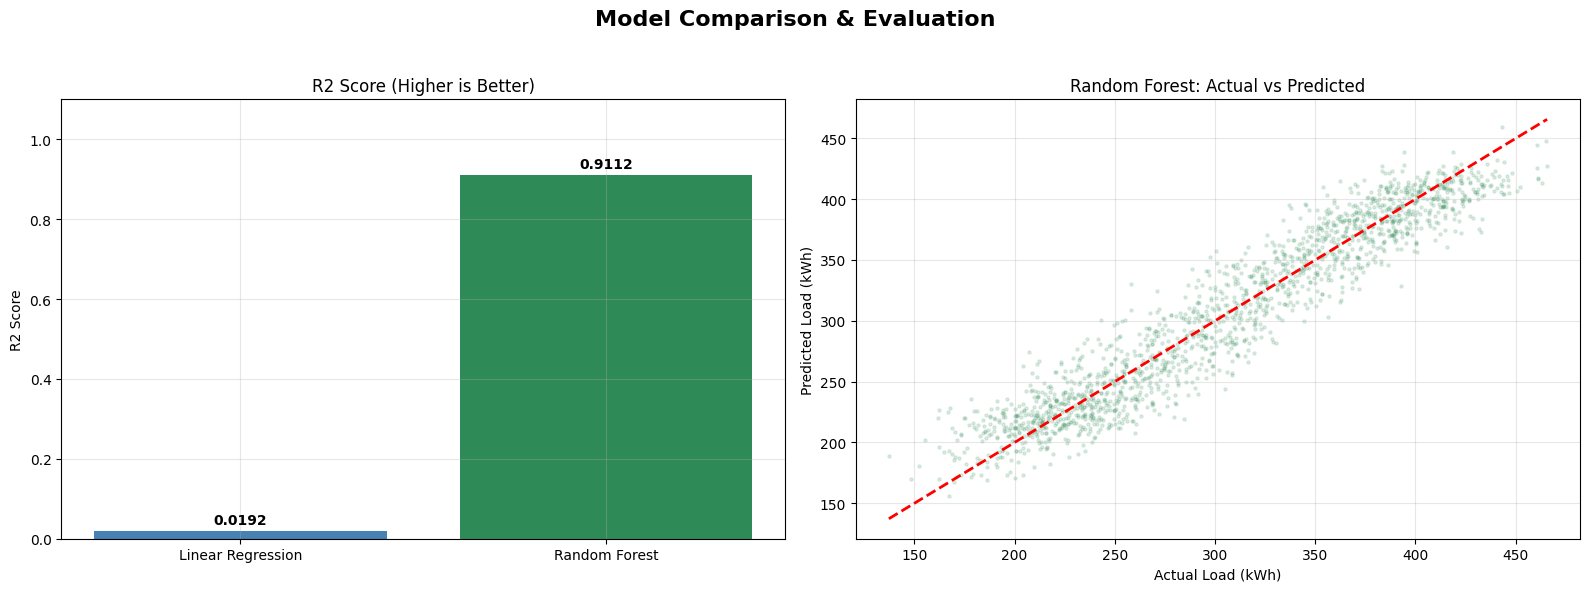

In [24]:
plt.figure(figsize=(16, 6))
plt.suptitle('Model Comparison & Evaluation', fontsize=16, fontweight='bold', y=0.98)

plt.subplot(1, 2, 1)
r2_bars = plt.bar(['Linear Regression', 'Random Forest'], [lr_r2, rf_r2], color=['steelblue', 'seagreen'])
plt.title('R2 Score (Higher is Better)')
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='-', alpha=0.3)

for bar in r2_bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_predictions, color='seagreen', alpha=0.15, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Load (kWh)')
plt.ylabel('Predicted Load (kWh)')
plt.grid(True, linestyle='-', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
new_input = pd.DataFrame({
    'hour'            : [18],
    'day_of_week'     : [0],
    'month'           : [7],
    'temperature'     : [35.0],
    'humidity'        : [60.0],
    'is_weekend'      : [0]
})

# Scale the input using the same scaler used in training
new_input_scaled = standard_scaler.transform(new_input)

pred_lr = lr_model.predict(new_input_scaled)[0]
pred_rf = rf_model.predict(new_input_scaled)[0]

print('Input: Monday 6 PM, July, 35 degrees, 60% humidity, Weekday')
print()
print('Predicted Electricity Load:')
print('  Linear Regression:', round(pred_lr, 2), 'kWh')
print('  Random Forest    :', round(pred_rf, 2), 'kWh')

Input: Monday 6 PM, July, 35 degrees, 60% humidity, Weekday

Predicted Electricity Load:
  Linear Regression: 321.59 kWh
  Random Forest    : 298.81 kWh
